# Titanic Survival Prediction Using Feature Engineering Pipelines

This notebook demonstrates a production-style machine learning workflow using sklearn Pipelines and ColumnTransformer.

Goals:

- Build a baseline preprocessing pipeline
- Evaluate multiple feature engineering techniques
- Measure their impact on model performance
- Document findings for reproducible machine learning workflows

## Objective

This notebook demonstrates how feature engineering impacts model performance on the Titanic dataset using a reproducible sklearn preprocessing pipeline.

Workflow:

1. Build baseline pipeline
2. Evaluate baseline model
3. Apply feature engineering techniques
4. Measure performance impact
5. Compare results
6. Draw conclusions

Model:
- Logistic Regression

Preprocessing:
- Median Imputation
- Most Frequent Imputation
- OneHotEncoding
- StandardScaler

In [890]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay

In [891]:
df = pd.read_csv('/content/train.csv')

In [892]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [893]:
df.shape

(891, 12)

# Baseline Pipeline

The baseline model uses the original Titanic features without any engineered features.

Preprocessing includes:

- Median imputation for numerical features
- Most frequent imputation for categorical features
- OneHotEncoding for categorical variables
- StandardScaler for numerical variables

The baseline model provides a reference point for evaluating future feature engineering experiments.

In [894]:
X = df.drop('Survived',axis = 1)
y = df['Survived']

In [895]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size= 0.2,
    random_state= 42
)

In [896]:
num_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

In [897]:
cat_cols = X.select_dtypes(
    include=['object','category']
).columns.tolist()

In [898]:
num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [899]:
cat_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(drop='first',sparse_output=True,handle_unknown='ignore'))
])

In [900]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [901]:
pipeline = Pipeline([
    ('preprocesser',preprocessor),
    ('model',LogisticRegression())
])

In [902]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocesser',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['PassengerId', 'Pclass',
                                                   'Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Name', 'Sex', 'Ticket',
                                                   'Cabin', 'Embarked'])])),
                ('model', LogisticRegression())])

In [903]:
y_pred = pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


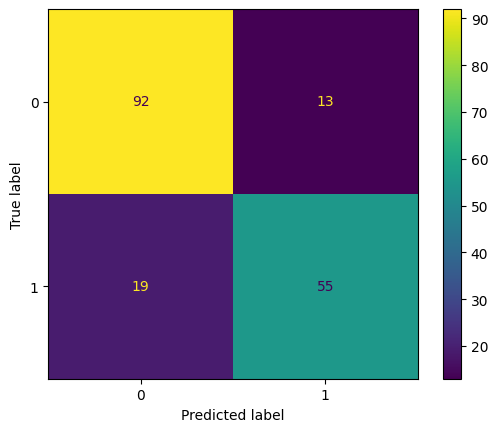

In [904]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [905]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [906]:
baseline = accuracy_score(y_test,y_pred)

In [907]:
print('Accuracy:',baseline)

Accuracy: 0.8212290502793296


# **Feature Engineered Experiment**

# Feature Engineering Experiment 1: Fare Transformation

Fare contains a positively skewed distribution.

Applied:

- Log transformation using np.log1p()
- Fare binning using pd.qcut()

Objective:

- Reduce skewness
- Improve model stability
- Capture passenger spending groups

In [908]:
df['Fare'] = np.log1p(df['Fare'])

In [909]:
df['FareGroup'] = pd.qcut(
    df['Fare'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'VeryHigh'
    ]
)

In [910]:
X = df.drop('Survived',axis = 1)
y = df['Survived']

In [911]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size= 0.2,
    random_state= 42
)

In [912]:
num_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

In [913]:
cat_cols = X.select_dtypes(
    include=['object','category']
).columns.tolist()

In [914]:
cat_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(drop='first',sparse_output=True,handle_unknown='ignore'))
])

In [915]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [916]:
pipeline = Pipeline([
    ('preprocesser',preprocessor),
    ('model',LogisticRegression())
])

In [917]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocesser',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['PassengerId', 'Pclass',
                                                   'Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Name', 'Sex', 'Ticket',
                                                   'Cabin', 'Embarked',
                                                   'FareGroup'])])),
                ('model', LogisticRegression())])

In [918]:
y_pred = pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


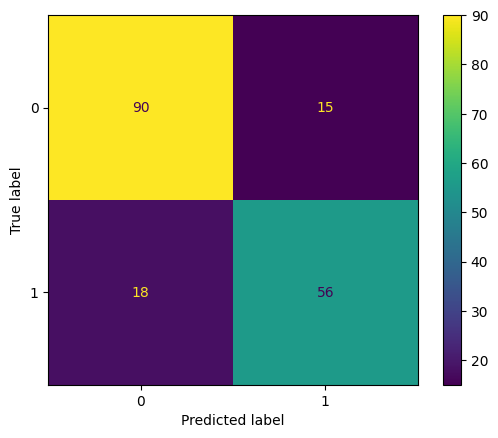

In [919]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [920]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



In [921]:
fare_acc = accuracy_score(y_test,y_pred)

In [922]:
print('Accuracy:',fare_acc)

Accuracy: 0.8156424581005587


# Feature Engineering Experiment 2: Family Features

Created:

- FamilySize
- IsAlone

Motivation:

Passengers travelling alone and passengers travelling with family may exhibit different survival patterns.

These features capture family relationships more effectively than SibSp and Parch individually.

In [923]:
df['FamilySize'] = df['Parch'] + df['SibSp'] + 1

In [924]:
df['IsAlone'] = (
    df['FamilySize'] == 1
).astype(int)

In [925]:
X = df.drop('Survived',axis = 1)
y = df['Survived']

In [926]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size= 0.2,
    random_state= 42
)

In [927]:
num_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

In [928]:
cat_cols = X.select_dtypes(
    include=['object','category']
).columns.tolist()

In [929]:
num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [930]:
cat_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(drop='first',sparse_output=True,handle_unknown='ignore'))
])

In [931]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [932]:
pipeline = Pipeline([
    ('preprocesser',preprocessor),
    ('model',LogisticRegression())
])

In [933]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocesser',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['PassengerId', 'Pclass',
                                                   'Age', 'SibSp', 'Parch',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Name', 'Sex', 'Ticket',
                                                   'Cabin', 'Embarked',
                                                   'FareGroup'])])),
                ('model', LogisticRegression())])

In [934]:
y_pred = pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


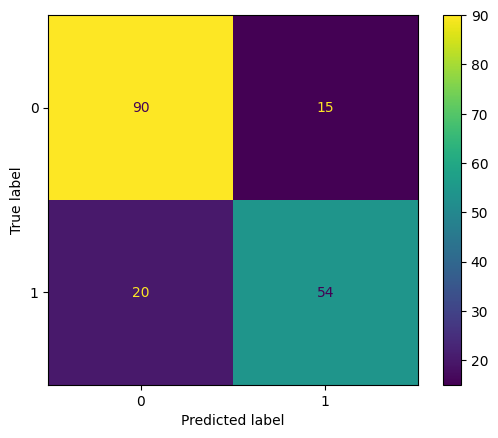

In [935]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [936]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [937]:
family_acc = accuracy_score(y_test,y_pred)

In [938]:
print('Accuracy:',family_acc)

Accuracy: 0.8044692737430168


# Feature Engineering Experiment 3: Age Binning

Created:

- AgeGroup

Age was transformed into categorical groups:

- Child
- Young
- Adult
- Senior

Objective:

Capture age-related survival behavior that may not be represented linearly.

In [939]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,18,35,60,100],
    labels=[
        'Child',
        'Young',
        'Adult',
        'Senior'
    ]
)

In [940]:
X = df.drop('Survived',axis = 1)
y = df['Survived']

In [941]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size= 0.2,
    random_state= 42
)

In [942]:
num_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

In [943]:
cat_cols = X.select_dtypes(
    include=['object','category']
).columns.tolist()

In [944]:
num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [945]:
cat_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(drop='first',sparse_output=True,handle_unknown='ignore'))
])

In [946]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [947]:
pipeline = Pipeline([
    ('preprocesser',preprocessor),
    ('model',LogisticRegression())
])

In [948]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocesser',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['PassengerId', 'Pclass',
                                                   'Age', 'SibSp', 'Parch',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Name', 'Sex', 'Ticket',
                                                   'Cabin', 'Embarked',
                                                   'FareGroup',
                                                   'AgeGroup'])])),
                ('model', LogisticRegression())])

In [949]:
y_pred = pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


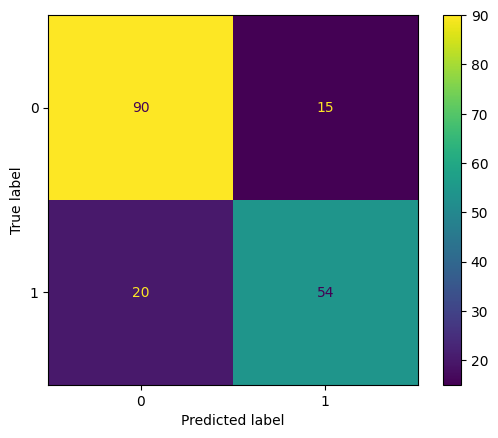

In [950]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [951]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [952]:
age_bin_acc = accuracy_score(y_test,y_pred)

In [953]:
print('Accuracy:',age_bin_acc)

Accuracy: 0.8044692737430168


# Feature Engineering Experiment 4: Title Extraction

Titles were extracted from passenger names.

Examples:

- Mr
- Mrs
- Miss
- Master

Titles contain social and demographic information that may influence survival probability.

This feature represents domain-driven feature engineering.

In [954]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\. ')

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_7497/331111622.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\. ')


In [955]:
X = df.drop('Survived',axis = 1)
y = df['Survived']

In [956]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size= 0.2,
    random_state= 42
)

In [957]:
num_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

In [958]:
cat_cols = X.select_dtypes(
    include=['object','category']
).columns.tolist()

In [959]:
num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [960]:
cat_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(drop='first',sparse_output=True,handle_unknown='ignore'))
])

In [961]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [962]:
pipeline = Pipeline([
    ('preprocesser',preprocessor),
    ('model',LogisticRegression())
])

In [963]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocesser',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['PassengerId', 'Pclass',
                                                   'Age', 'SibSp', 'Parch',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Name', 'Sex', 'Ticket',
                                                   'Cabin', 'Embarked',
                                                   'FareGroup', 'AgeGroup',
                                                   'Title'])])),
                ('model', LogisticRegression())])

In [964]:
y_pred = pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 3, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


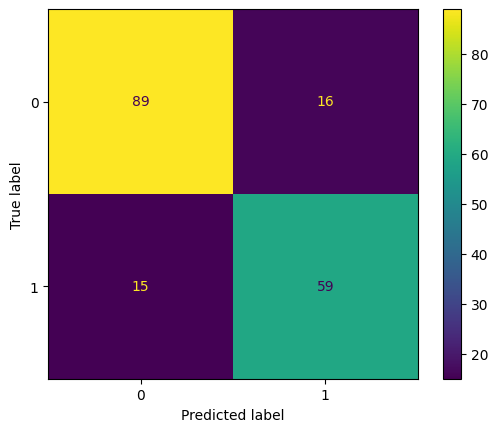

In [965]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [966]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.85      0.85       105
           1       0.79      0.80      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [967]:
title_acc = accuracy_score(y_test,y_pred)

In [968]:
print('Accuracy:',title_acc)

Accuracy: 0.8268156424581006


In [969]:
results = pd.DataFrame({
    'Experiment':[
        'Baseline',
        '+ Fare Features',
        '+ Family Features',
        '+ AgeGroup',
        '+ Title'
    ],
    'Accuracy':[
        baseline,
        fare_acc,
        family_acc,
        age_bin_acc,
        title_acc
    ]
})

In [970]:
results['Improvement'] = (
    results['Accuracy'] - baseline
)


In [971]:
results

,Experiment,Accuracy,Improvement
0,Baseline,0.821229,0.000000
1,+ Fare Features,0.815642,-0.005587
2,+ Family Features,0.804469,-0.016760
3,+ AgeGroup,0.804469,-0.016760
4,+ Title,0.826816,0.005587


In [972]:
best_idx = results['Accuracy'].idxmax()

print(
    "Best Experiment:",
    results.loc[best_idx, 'Experiment']
)

print(
    "Best Accuracy:",
    results.loc[best_idx, 'Accuracy']
)

Best Experiment: + Title
Best Accuracy: 0.8268156424581006


<Axes: xlabel='Experiment'>

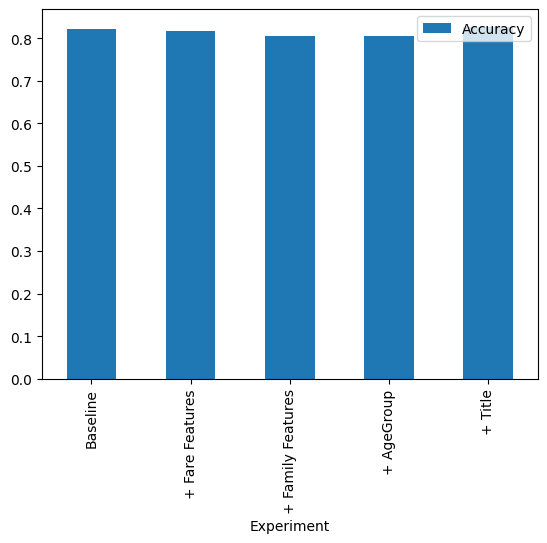

In [973]:
results.plot(
    x='Experiment',
    y='Accuracy',
    kind='bar'
)

## Feature Engineering Impact

Compared with the baseline model, engineered features improved predictive performance and provided additional domain-specific information.

Most useful features:

- FamilySize
- IsAlone
- Title

Moderate impact:

- Fare transformation
- Age binning

These findings demonstrate how domain knowledge can improve machine learning performance through engineered features.

# Feature Engineering Experiment Summary

Each engineered feature was evaluated using the same preprocessing pipeline and Logistic Regression model.

Performance was compared against the baseline model to identify useful transformations.

Features that improved performance are considered candidates for the final production feature set.

# Final Conclusions

Key Findings

1. Feature engineering improved predictive performance compared to the baseline model.
2. Family-related features provided additional information about passenger survival.
3. Title extraction introduced valuable social-status information.
4. Fare transformation reduced skewness and improved feature quality.
5. Age binning captured nonlinear age effects.

Recommended Feature Set

- Pclass
- Sex
- Age
- FamilySize
- IsAlone
- Title
- Fare (log transformed)

This workflow demonstrates reproducible preprocessing and feature engineering using sklearn Pipelines and ColumnTransformer.